<a href="https://colab.research.google.com/github/nabilanisa1504/Pengolahan-Citra/blob/main/JOBSHEET04_SEGMENTASI_GAMBAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

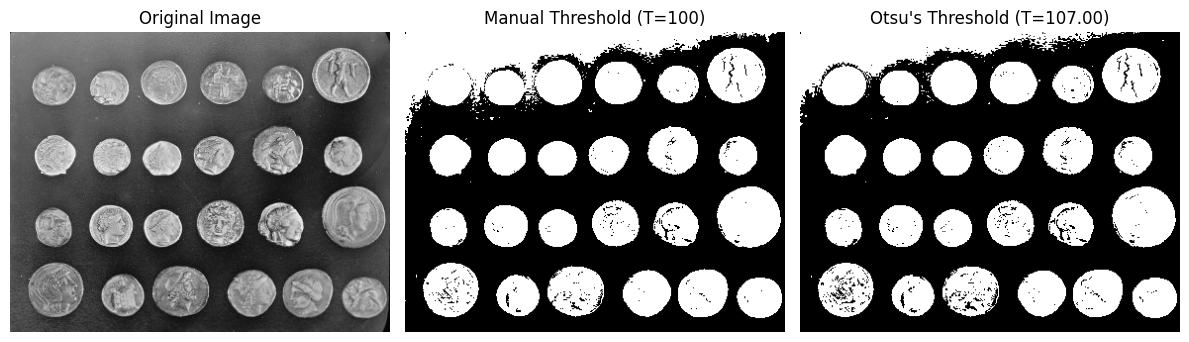

Nilai threshold Otsu yang ditemukan: 107


In [7]:
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()  # Citra sudah grayscale

# 2. Thresholding Global (manual)
# Tentukan nilai ambang manual, misal 100
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f"Otsu's Threshold (T={thresh_otsu:.2f})")
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

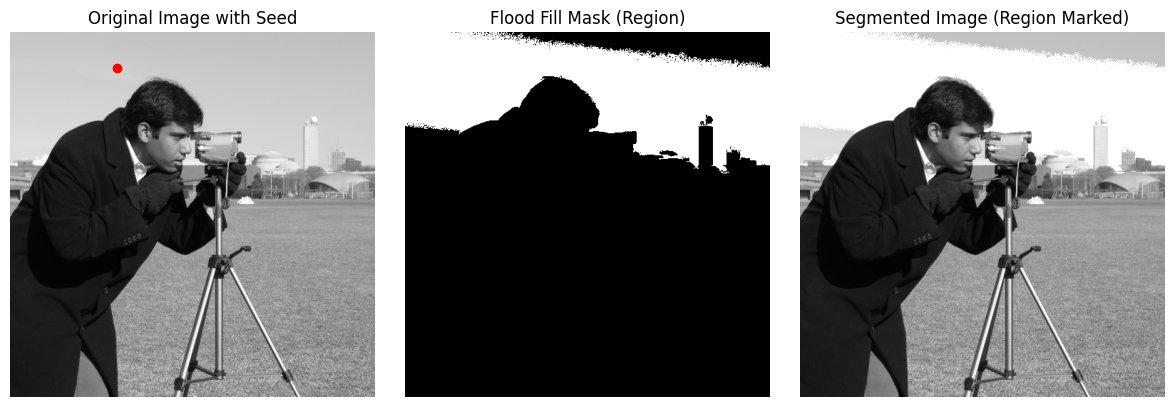

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

# 1. Memuat citra (contoh: camera)
image_camera = data.camera()

# 2. Tentukan titik 'seed' (benih)
# Misal, kita pilih titik di area langit (koordinat y=50, x=150)
seed_point = (50, 150)

# 3. Terapkan algoritma flood fill (mirip region growing)
# 'tolerance' menentukan seberapa besar perbedaan intensitas yang diizinkan
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Buat citra tersegmentasi (tandai region yang 'tumbuh')
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255  # Tandai region dengan warna putih

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro')  # Tandai seed point
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

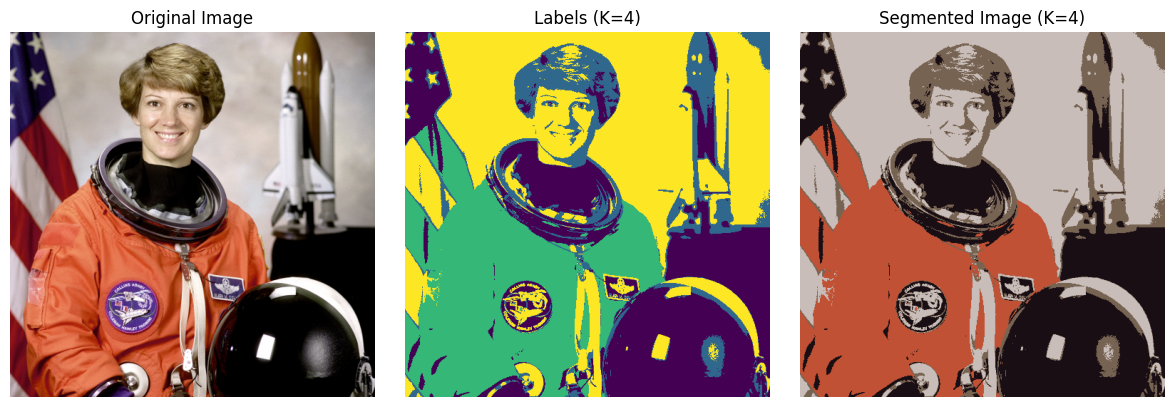

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. Memuat citra berwarna (contoh: astronaut)
image_astro = data.astronaut()

# Konversi ke float
image_astro_float = image_astro.astype(float) / 255.0

# 2. Konversi ke ruang warna Lab
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape

# Reshape menjadi array piksel
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. K-Means Clustering
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Kembalikan ke bentuk citra
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Buat citra hasil segmentasi
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_

for k in range(n_clusters):
    mask_k = (pixel_labels == k).reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Konversi kembali ke RGB
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# 6. Visualisasi
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'Labels (K={n_clusters})')
ax[1].axis('off')

ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

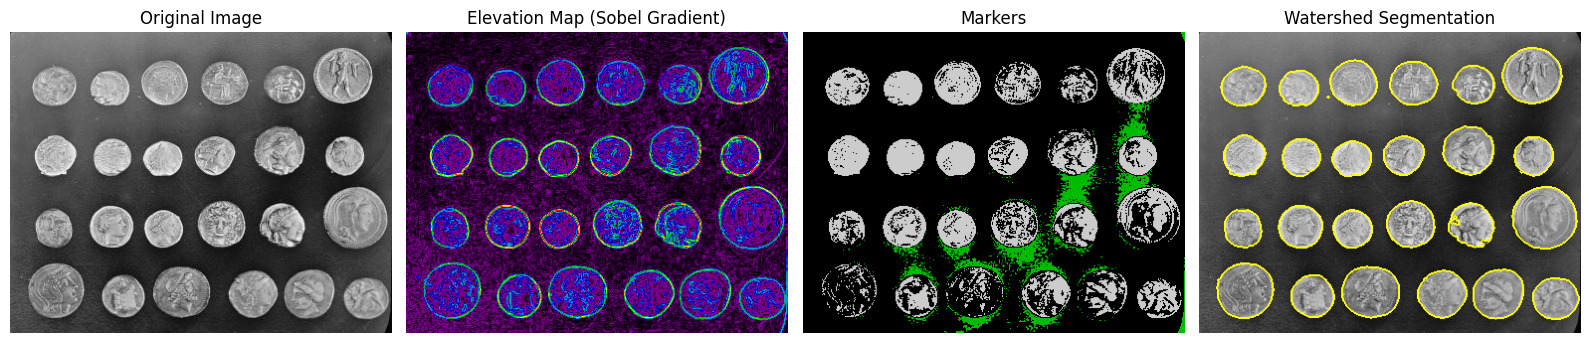

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()

# 2. Hitung gradien citra (sebagai 'topografi')
elevation_map = filters.sobel(image_coins)

# 3. Tentukan marker (penanda awal)
markers = np.zeros_like(image_coins)

# Marker untuk background
markers[image_coins < 30] = 1

# Marker untuk objek (koin)
markers[image_coins > 150] = 2

# Alternatif marker (lebih canggih - optional)
# from skimage.feature import peak_local_max
# image_max = ndi.maximum_filter(image_coins, size=20, mode='constant')
# coordinates = peak_local_max(image_coins, min_distance=20)
# markers = np.zeros(image_coins.shape, dtype=bool)
# markers[tuple(coordinates.T)] = True
# markers = measure.label(markers)

# 4. Terapkan algoritma Watershed
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 5. Tandai batas hasil segmentasi
segmented_colored = segmentation.mark_boundaries(
    image_coins, segmentation_watershed
)

# 6. Visualisasi
fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()

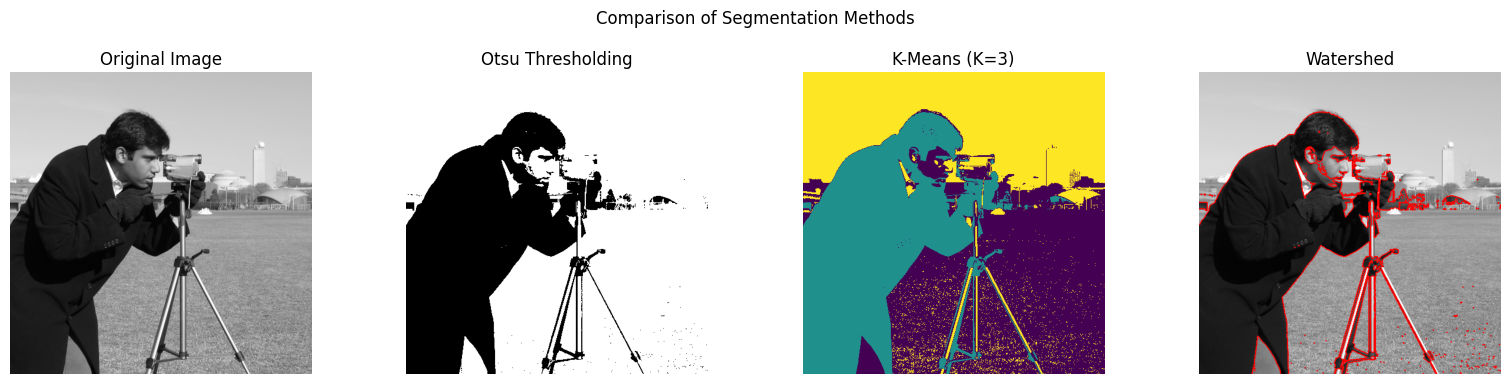

In [11]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Ambil citra (contoh: camera)
image = data.camera()
image_float = img_as_float(image)

# 2. Segmentasi

# a) Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b) K-Means (K = 3)
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# c) Watershed (marker dari Otsu)
elevation_map = filters.sobel(image)

markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2

segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 3. Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

# Original
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

# Otsu
ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

# K-Means
ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

# Watershed
segmented_watershed_colored = segmentation.mark_boundaries(
    image_float,
    segmentation_watershed,
    color=(1, 0, 0)
)

ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

PENUGASAN


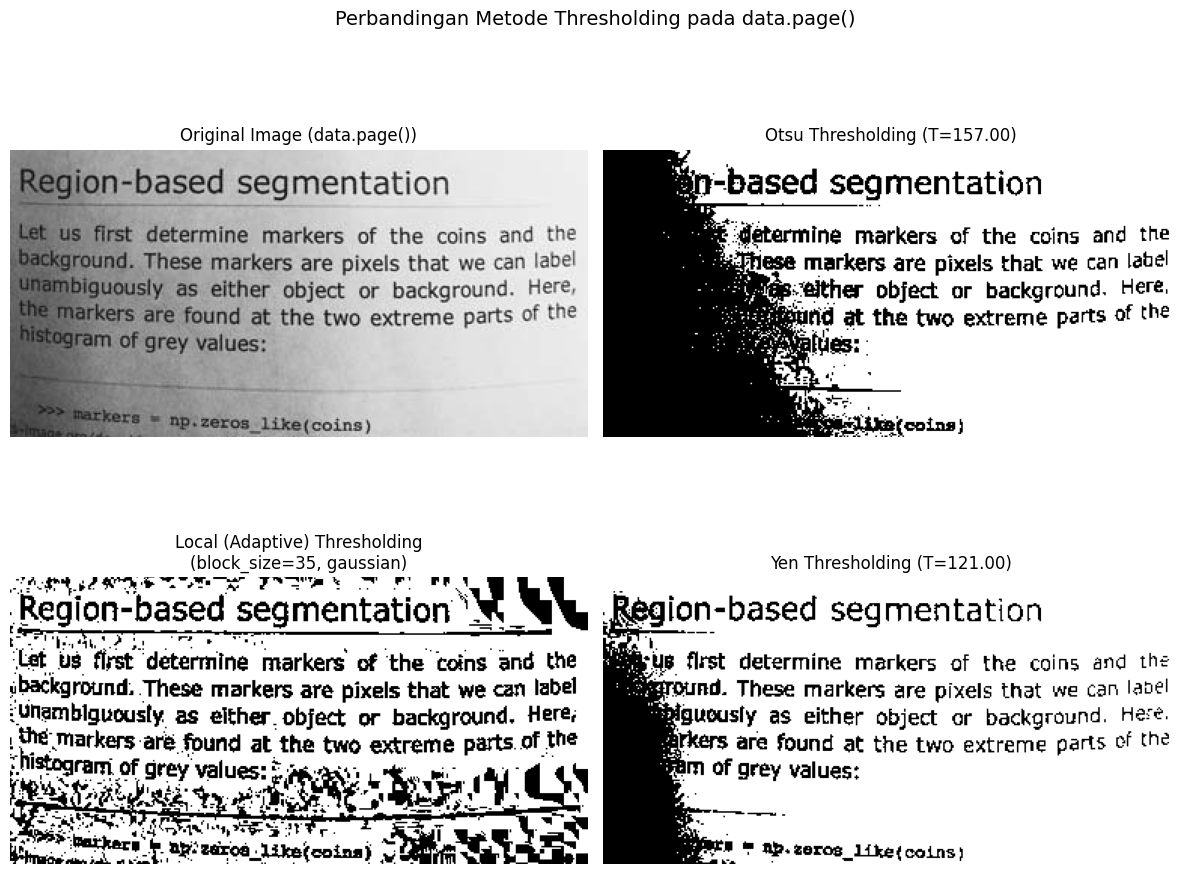

Threshold Otsu : 157.00
Threshold Yen  : 121.00


In [12]:
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.color import rgb2gray
import numpy as np

# 1. Memuat citra data.page()
image_page = data.page()

# 2. Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_page)
binary_otsu = image_page > thresh_otsu

# 3. Thresholding Local (Adaptive)
thresh_local = filters.threshold_local(image_page, block_size=35, method='gaussian')
binary_local = image_page > thresh_local

# 4. Thresholding Yen
thresh_yen = filters.threshold_yen(image_page)
binary_yen = image_page > thresh_yen

# 5. Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax = axes.ravel()

ax[0].imshow(image_page, cmap='gray')
ax[0].set_title('Original Image (data.page())')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title(f'Otsu Thresholding (T={thresh_otsu:.2f})')
ax[1].axis('off')

ax[2].imshow(binary_local, cmap='gray')
ax[2].set_title('Local (Adaptive) Thresholding\n(block_size=35, gaussian)')
ax[2].axis('off')

ax[3].imshow(binary_yen, cmap='gray')
ax[3].set_title(f'Yen Thresholding (T={thresh_yen:.2f})')
ax[3].axis('off')

plt.suptitle('Perbandingan Metode Thresholding pada data.page()', fontsize=14)
plt.tight_layout()
plt.savefig('penugasan1_thresholding_page.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Threshold Otsu : {thresh_otsu:.2f}")
print(f"Threshold Yen  : {thresh_yen:.2f}")

Saving gambar_uji.jpg to gambar_uji.jpg


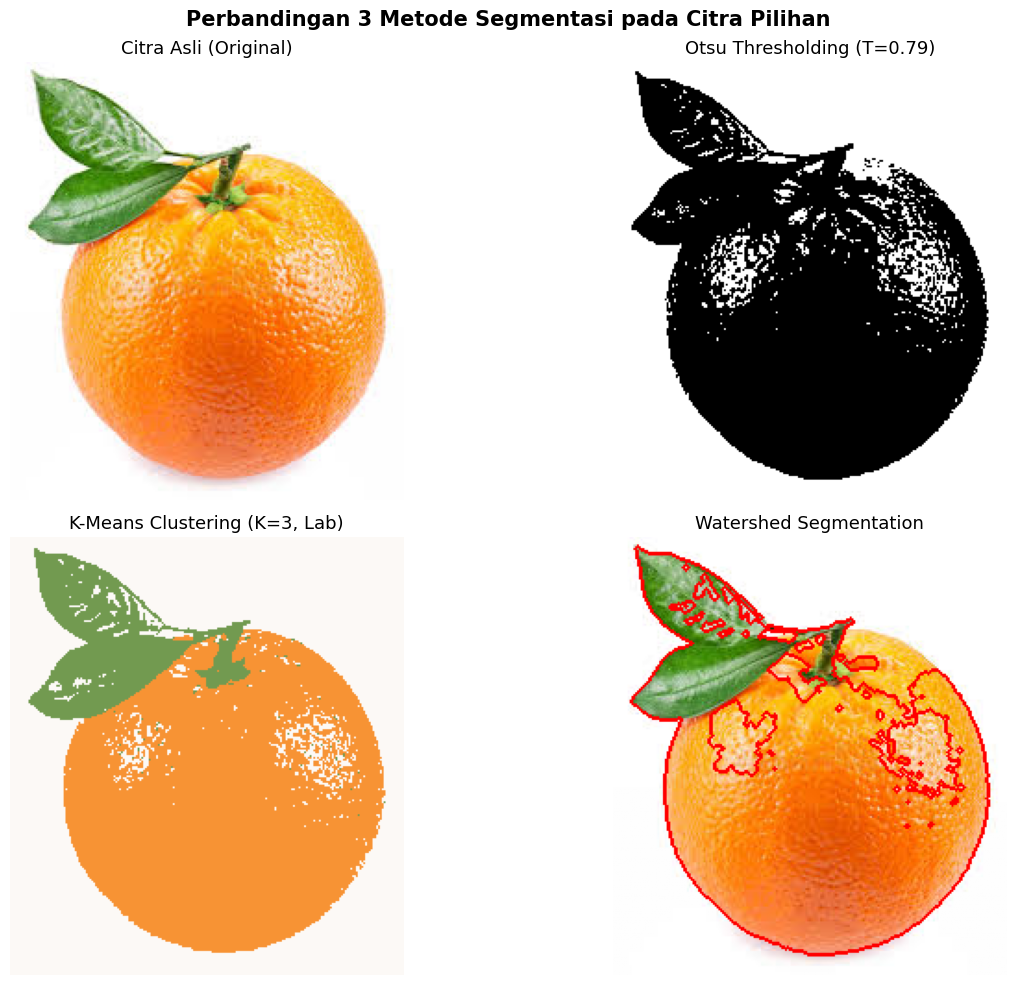

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from skimage import io, filters, segmentation, img_as_float
from skimage.color import rgb2gray, rgb2lab, lab2rgb
from sklearn.cluster import KMeans
from google.colab import files

# Upload gambar dari komputer
uploaded = files.upload()  # pilih gambar_uji.jpg

# Muat citra
image_rgb = io.imread('gambar_uji.jpg')
image_gray = rgb2gray(image_rgb)
image_float = img_as_float(image_rgb)

# ── Metode A: Otsu Thresholding ──────────────────────────────
thresh_otsu = filters.threshold_otsu(image_gray)
binary_otsu = image_gray > thresh_otsu

# ── Metode B: K-Means Clustering (K=3) ───────────────────────
image_lab = rgb2lab(image_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_labels = pixel_labels.reshape(rows, cols)
segmented_lab = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_
for k in range(n_clusters):
    mask_k = segmented_labels == k
    segmented_lab[mask_k] = centers_lab[k]
segmented_rgb = lab2rgb(segmented_lab)

# ── Metode C: Watershed Segmentation ─────────────────────────
elevation_map = filters.sobel(image_gray)
markers = np.zeros_like(image_gray, dtype=int)
markers[image_gray < thresh_otsu * 0.7] = 1
markers[image_gray > thresh_otsu * 1.1] = 2
segmentation_ws = segmentation.watershed(elevation_map, markers)
segmented_ws_colored = segmentation.mark_boundaries(
    image_float, segmentation_ws, color=(1, 0, 0)
)

# ── Visualisasi ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax = axes.ravel()

ax[0].imshow(image_rgb)
ax[0].set_title('Citra Asli (Original)', fontsize=13)
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title(f'Otsu Thresholding (T={thresh_otsu:.2f})', fontsize=13)
ax[1].axis('off')

ax[2].imshow(segmented_rgb)
ax[2].set_title(f'K-Means Clustering (K={n_clusters}, Lab)', fontsize=13)
ax[2].axis('off')

ax[3].imshow(segmented_ws_colored)
ax[3].set_title('Watershed Segmentation', fontsize=13)
ax[3].axis('off')

plt.suptitle('Perbandingan 3 Metode Segmentasi pada Citra Pilihan', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('penugasan2_segmentasi_perbandingan.png', dpi=150, bbox_inches='tight')
plt.show()